# Phase 2: OCR 

In this phase we will explore several open source OCR model on our articles and compare the results to the md files Hugging Face produced with chandra2. 

In [1]:
import os
from dotenv import load_dotenv
_ = load_dotenv(override=True)

In [2]:
# Pointe le client chandra vers notre serveur vLLM (nom DNS sur scirex-net).
# Doit être fait AVANT d'importer chandra.model.vllm car settings est chargé à l'import.
os.environ["VLLM_API_BASE"] = "http://chandra-vllm:8000/v1"
os.environ["VLLM_MODEL_NAME"] = "chandra"

In [4]:
from PIL import Image
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Dict, Any
import duckdb
from pdf2image import convert_from_path
import os


from chandra.model.vllm import generate_vllm
from chandra.model.schema import BatchInputItem
from chandra.output import parse_markdown, parse_chunks
from IPython.display import Markdown, display

import time
import pymupdf
from PIL import Image
import io

# Chandra 2 - OCR

Chandra2 is developped by Datalab and is an open source VLM very good for OCR scientific articles from ArXiv. Inference can be done locally with 2 methods: transformers from HuggingFace or through a vLLM server. Let's compare both ways of running. 

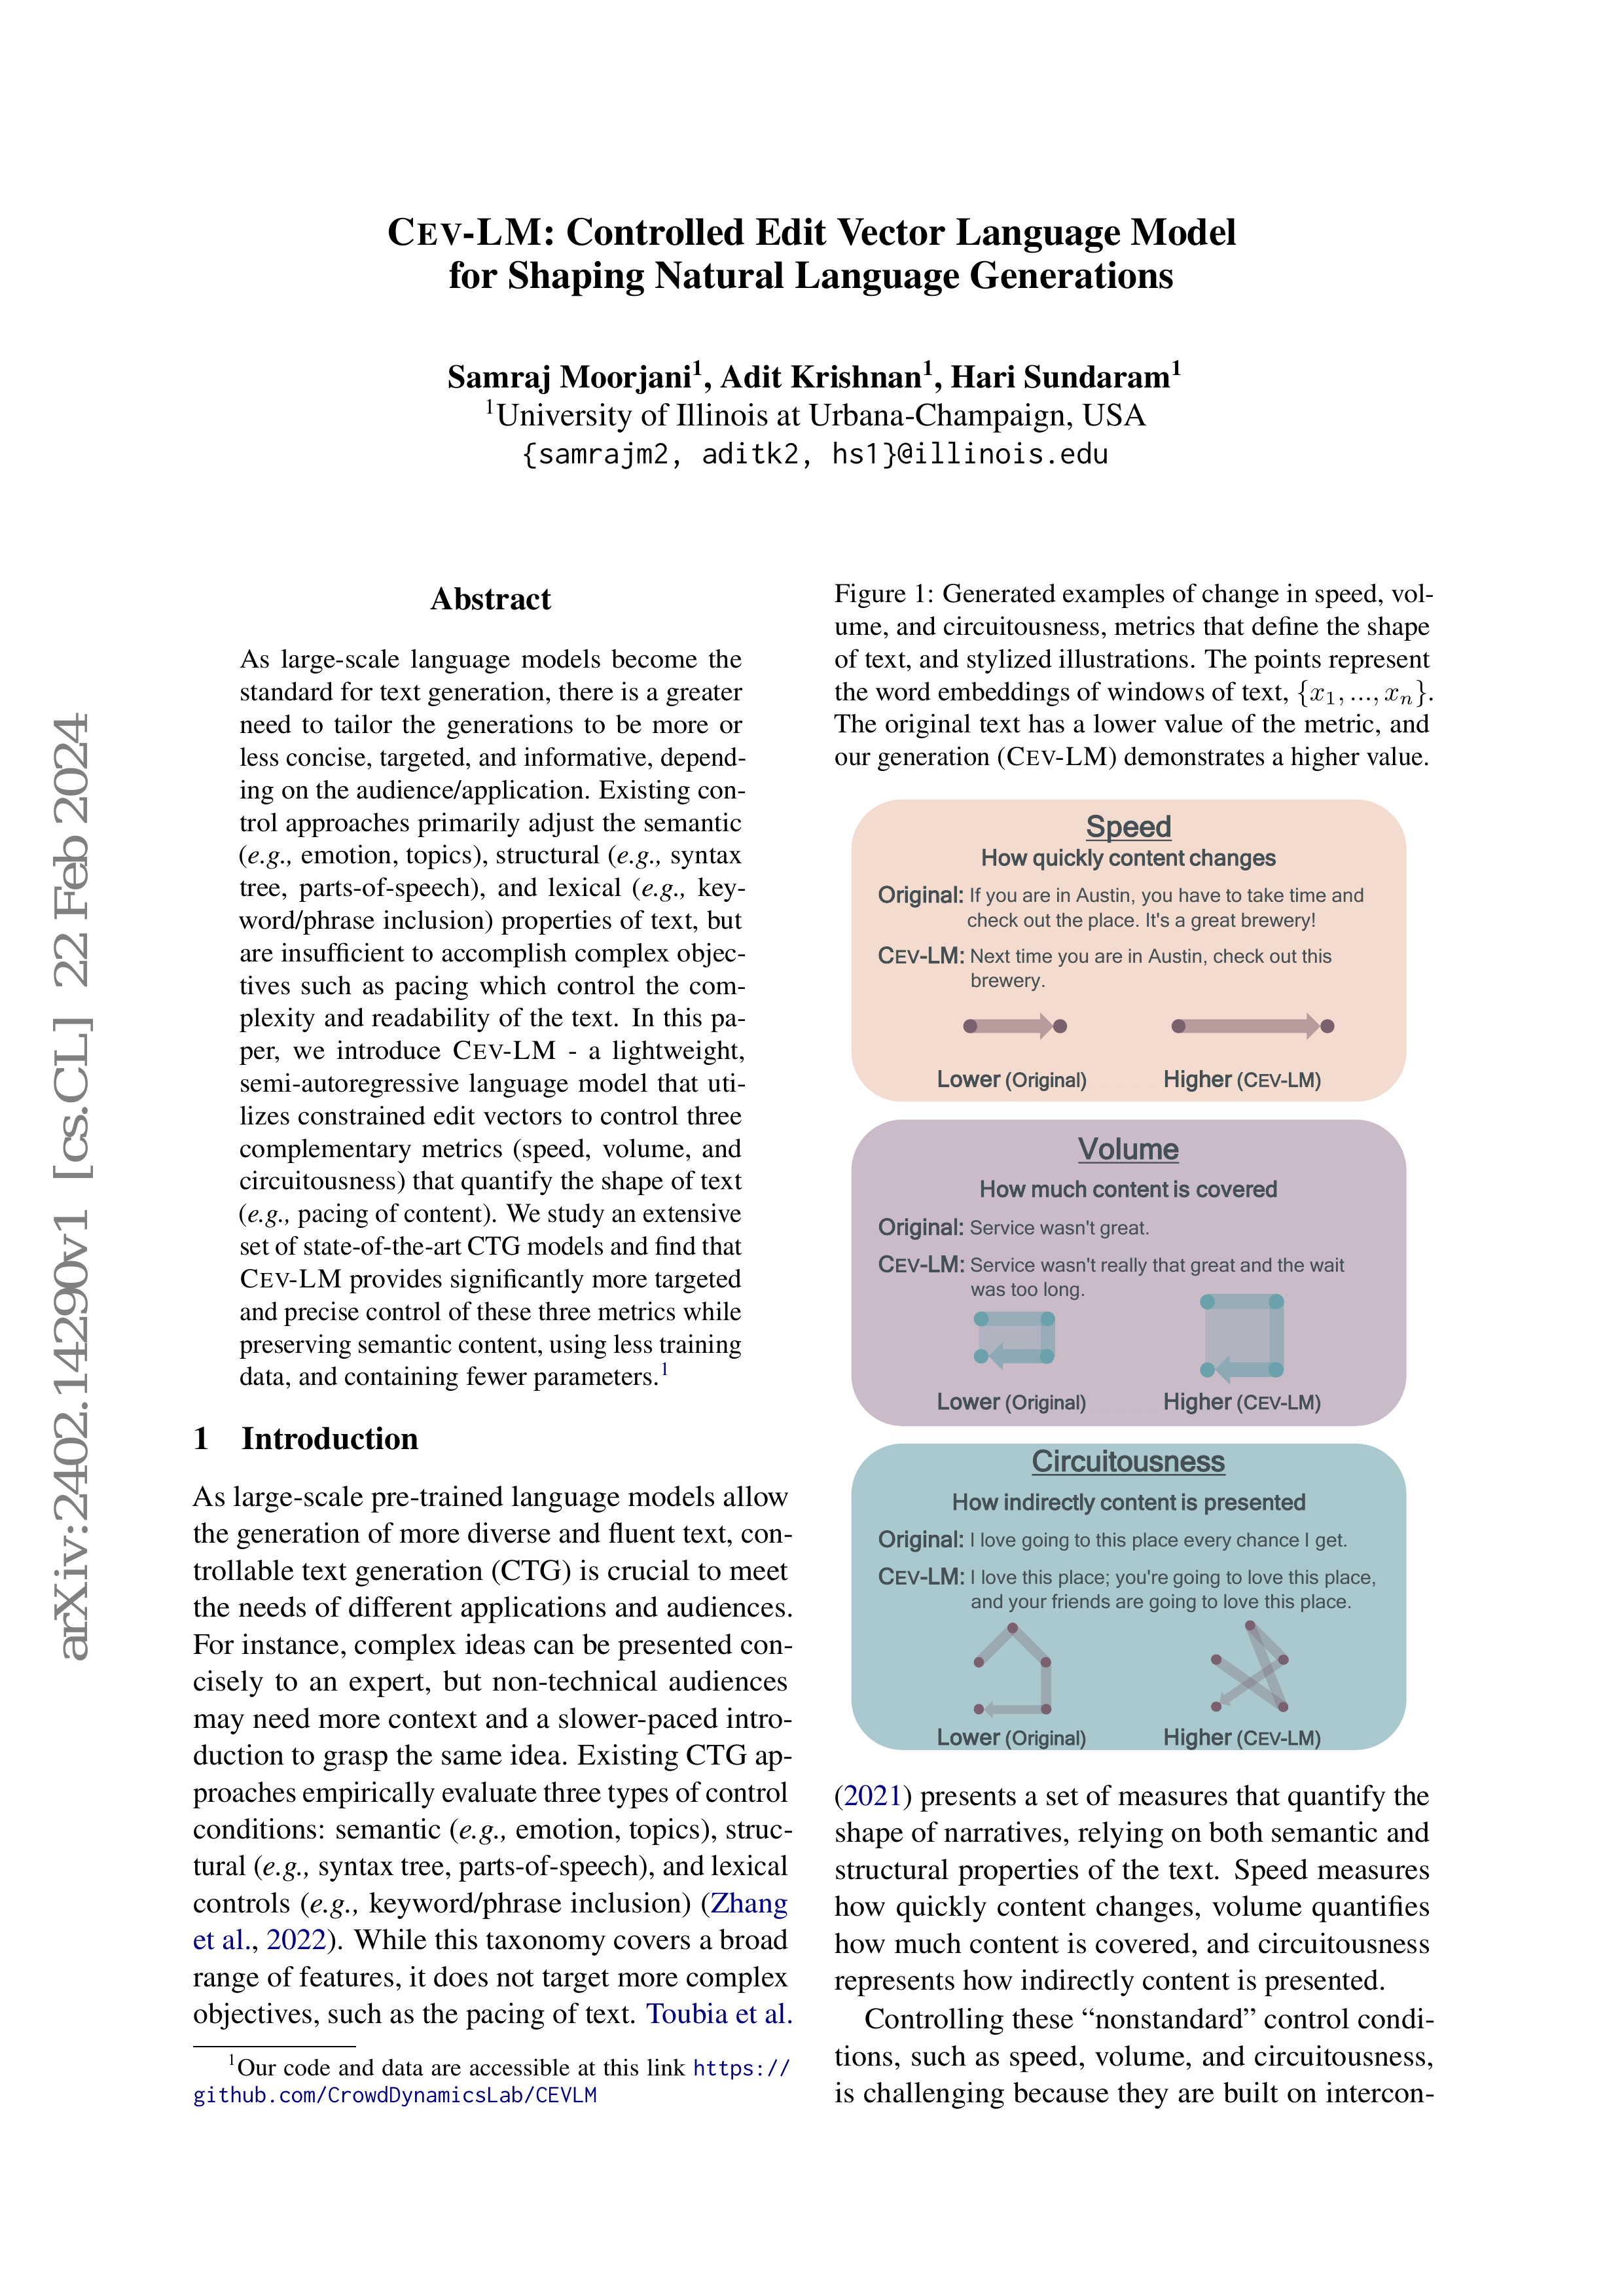

True

In [2]:
from PIL import Image, ImageShow

image=Image.open("data/sample_page.png")
ImageShow.show(image)

In [4]:
from transformers import AutoModelForImageTextToText, AutoProcessor, TorchAoConfig
from torchao.quantization import Int8WeightOnlyConfig
from chandra.model.hf import generate_hf
from chandra.model.schema import BatchInputItem
from chandra.output import parse_markdown
from PIL import Image
import torch, gc, time

gc.collect()
torch.cuda.empty_cache()

quant_config = TorchAoConfig(quant_type=Int8WeightOnlyConfig())

model = AutoModelForImageTextToText.from_pretrained(
    "datalab-to/chandra-ocr-2",
    quantization_config=quant_config,
    device_map="auto",
    attn_implementation="flash_attention_2",
)
model.eval()

# Vérif FA2 (après création)
print("attn impl:", model.config._attn_implementation)
if hasattr(model.model, "language_model"):
    print("language model attn:", model.model.language_model.config._attn_implementation)

# Processor
model.processor = AutoProcessor.from_pretrained("datalab-to/chandra-ocr-2")
model.processor.tokenizer.padding_side = "left"

# Inspecte ce que le processor expose comme bornes
ip = model.processor.image_processor
print("image processor type:", type(ip).__name__)
for attr in ("min_pixels", "max_pixels", "size", "do_resize"):
    if hasattr(ip, attr):
        print(f"  {attr} = {getattr(ip, attr)}")

# Inférence test
batch = [BatchInputItem(image=Image.open("data/sample_page.png"), prompt_type="ocr_layout")]

with torch.inference_mode():
    t0 = time.time()
    result = generate_hf(batch, model, max_output_tokens=4096)[0]
    print(f"OCR took {time.time()-t0:.1f}s")

print(parse_markdown(result.raw))

/usr/local/lib/python3.12/dist-packages/torch/library.py:357: UserWarning: Warning only once for all operators,  other operators may also be overridden.
  Overriding a previously registered kernel for the same operator and the same dispatch key
  operator: flash_attn::_flash_attn_backward(Tensor dout, Tensor q, Tensor k, Tensor v, Tensor out, Tensor softmax_lse, Tensor(a6!)? dq, Tensor(a7!)? dk, Tensor(a8!)? dv, float dropout_p, float softmax_scale, bool causal, SymInt window_size_left, SymInt window_size_right, float softcap, Tensor? alibi_slopes, bool deterministic, Tensor? rng_state=None) -> Tensor
    registered at /usr/local/lib/python3.12/dist-packages/torch/_library/custom_ops.py:926
  dispatch key: ADInplaceOrView
  previous kernel: no debug info
       new kernel: registered at /usr/local/lib/python3.12/dist-packages/torch/_library/custom_ops.py:926 (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/core/dispatch/OperatorEntry.cpp:208.)
  self.m.impl(
[transformers] T

attn impl: flash_attention_2
language model attn: flash_attention_2


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


image processor type: Qwen2VLImageProcessor
  size = SizeDict(height=None, width=None, longest_edge=16777216, shortest_edge=65536, max_height=None, max_width=None)
  do_resize = True


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


OCR took 63.4s
# CEV-LM: Controlled Edit Vector Language Model for Shaping Natural Language Generations

Samraj Moorjani<sup>1</sup>, Adit Krishnan<sup>1</sup>, Hari Sundaram<sup>1</sup>

<sup>1</sup>University of Illinois at Urbana-Champaign, USA

{samrajm2, aditk2, hs1}@illinois.edu

## Abstract

As large-scale language models become the standard for text generation, there is a greater need to tailor the generations to be more or less concise, targeted, and informative, depending on the audience/application. Existing control approaches primarily adjust the semantic (*e.g.*, emotion, topics), structural (*e.g.*, syntax tree, parts-of-speech), and lexical (*e.g.*, keyword/phrase inclusion) properties of text, but are insufficient to accomplish complex objectives such as pacing which control the complexity and readability of the text. In this paper, we introduce CEV-LM - a lightweight, semi-autoregressive language model that utilizes constrained edit vectors to control three complementa

# CEV-LM: Controlled Edit Vector Language Model for Shaping Natural Language Generations

Samraj Moorjani<sup>1</sup>, Adit Krishnan<sup>1</sup>, Hari Sundaram<sup>1</sup>

<sup>1</sup>University of Illinois at Urbana-Champaign, USA

{samrajm2, aditk2, hs1}@illinois.edu

## Abstract

As large-scale language models become the standard for text generation, there is a greater need to tailor the generations to be more or less concise, targeted, and informative, depending on the audience/application. Existing control approaches primarily adjust the semantic (*e.g.*, emotion, topics), structural (*e.g.*, syntax tree, parts-of-speech), and lexical (*e.g.*, keyword/phrase inclusion) properties of text, but are insufficient to accomplish complex objectives such as pacing which control the complexity and readability of the text. In this paper, we introduce CEV-LM - a lightweight, semi-autoregressive language model that utilizes constrained edit vectors to control three complementary metrics (speed, volume, and circuitousness) that quantify the shape of text (*e.g.*, pacing of content). We study an extensive set of state-of-the-art CTG models and find that CEV-LM provides significantly more targeted and precise control of these three metrics while preserving semantic content, using less training data, and containing fewer parameters.<sup>1</sup>

## 1 Introduction

As large-scale pre-trained language models allow the generation of more diverse and fluent text, controllable text generation (CTG) is crucial to meet the needs of different applications and audiences. For instance, complex ideas can be presented concisely to an expert, but non-technical audiences may need more context and a slower-paced introduction to grasp the same idea. Existing CTG approaches empirically evaluate three types of control conditions: semantic (*e.g.*, emotion, topics), structural (*e.g.*, syntax tree, parts-of-speech), and lexical controls (*e.g.*, keyword/phrase inclusion) (Zhang et al., 2022). While this taxonomy covers a broad range of features, it does not target more complex objectives, such as the pacing of text. Toubia et al.

<sup>1</sup>Our code and data are accessible at this link <https://github.com/CrowdDynamicsLab/CEVLM>

Figure 1: Generated examples of change in speed, volume, and circuitousness, metrics that define the shape of text, and stylized illustrations. The points represent the word embeddings of windows of text,  $\{x_1, \dots, x_n\}$ . The original text has a lower value of the metric, and our generation (CEV-LM) demonstrates a higher value.

![Figure 1: Three panels illustrating text generation metrics: Speed, Volume, and Circuitousness. Each panel shows a comparison between 'Original' and 'CEV-LM' text, with corresponding stylized illustrations of word embeddings.](abb9e86dbf4785ce08052e6eaf89f36d_12_img.webp)

**Speed**  
How quickly content changes

**Original:** If you are in Austin, you have to take time and check out the place. It's a great brewery!

**CEV-LM:** Next time you are in Austin, check out this brewery.

Lower (Original)      Higher (CEV-LM)

**Volume**  
How much content is covered

**Original:** Service wasn't great.

**CEV-LM:** Service wasn't really that great and the wait was too long.

Lower (Original)      Higher (CEV-LM)

**Circuitousness**  
How indirectly content is presented

**Original:** I love going to this place every chance I get.

**CEV-LM:** I love this place; you're going to love this place, and your friends are going to love this place.

Lower (Original)      Higher (CEV-LM)

(2021) presents a set of measures that quantify the shape of narratives, relying on both semantic and structural properties of the text. Speed measures how quickly content changes, volume quantifies how much content is covered, and circuitousness represents how indirectly content is presented.

Controlling these “nonstandard” control conditions, such as speed, volume, and circuitousness, is challenging because they are built on intercon-

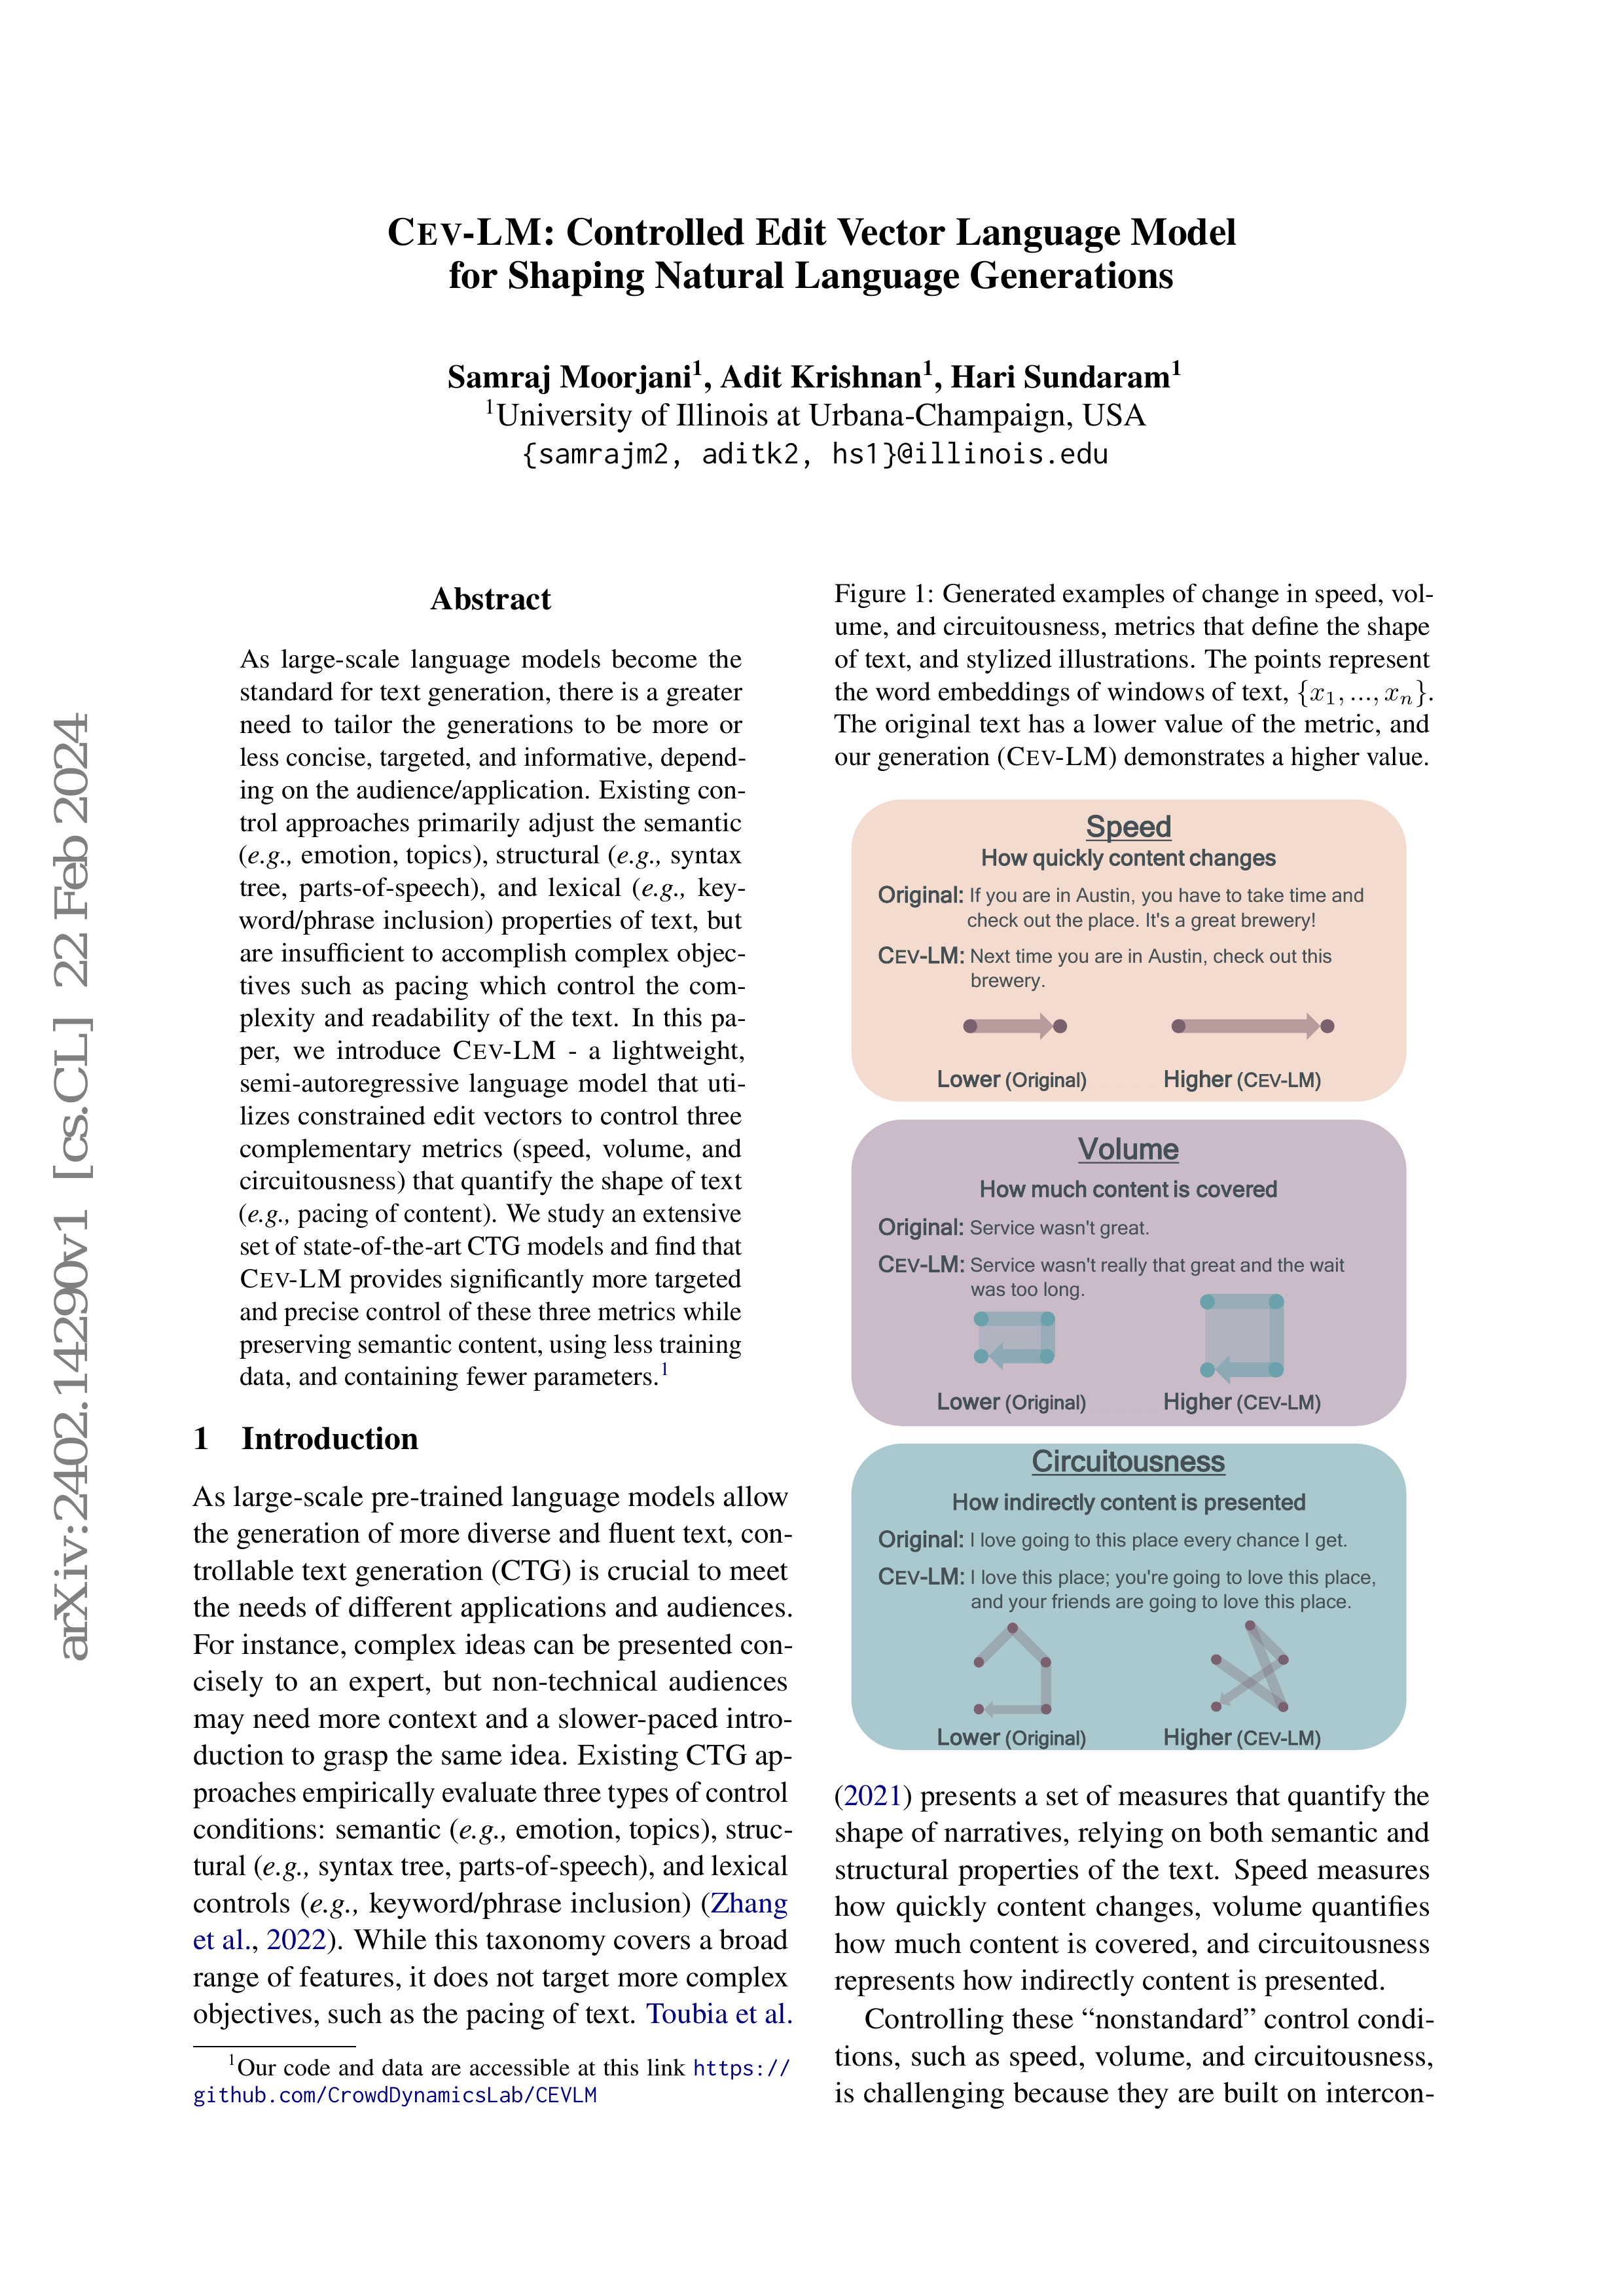

True

In [9]:
ImageShow.show(Image.open("data/sample_page.png"))

In [5]:
# Vérifie que le GPU est disponible
print(f"CUDA disponible : {torch.cuda.is_available()}")
print(f"PyTorch : {torch.__version__}")

CUDA disponible : True
PyTorch : 2.10.0a0+a36e1d39eb.nv26.01.42222806


In [6]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM free: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Ti
VRAM total: 16.6 GB
VRAM free: 8.5 GB


In [7]:
from transformers import AutoModelForImageTextToText, AutoProcessor, TorchAoConfig
from torchao.quantization import Int8WeightOnlyConfig
import torch, gc

gc.collect()
torch.cuda.empty_cache()

quant_config = TorchAoConfig(quant_type=Int8WeightOnlyConfig())

model = AutoModelForImageTextToText.from_pretrained(
    "datalab-to/chandra-ocr-2",
    quantization_config=quant_config,
    device_map="auto",
    attn_implementation="flash_attention_2",
)
model.eval()

processor = AutoProcessor.from_pretrained("datalab-to/chandra-ocr-2")
processor.tokenizer.padding_side = "left"
model.processor = processor

# Vérifications
print(f"attn impl: {model.config._attn_implementation}")
print(f"VRAM used: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

Loading weights: 100%|██████████| 724/724 [00:00<00:00, 838.14it/s] 


attn impl: flash_attention_2
VRAM used: 5.2 GB


PDF total pages: 19, loaded: 5
First page size: (1632, 2112)


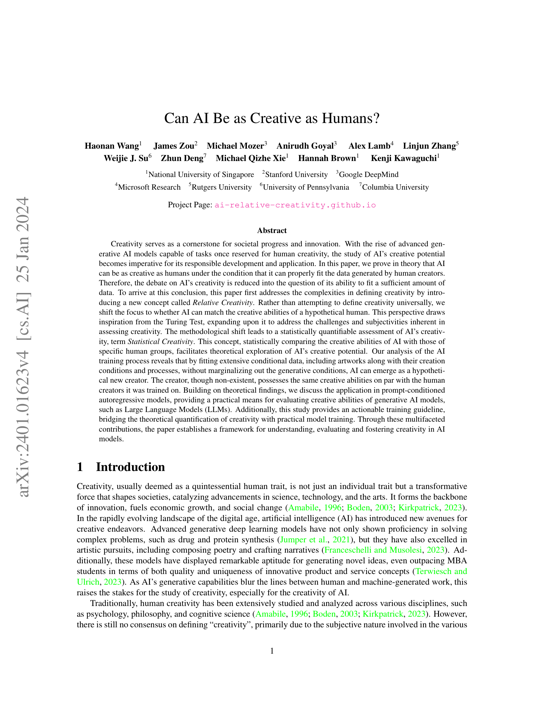

In [8]:
import pymupdf
from PIL import Image
import io

pdf_path = "data/raw/pdfs/2401.01623.pdf"
max_pages = 5   # commence petit pour debug, on monte à 30 plus tard
dpi = 192       # défaut de Chandra. Plus haut = plus précis mais plus lourd

doc = pymupdf.open(pdf_path)
n_total = doc.page_count
n = min(max_pages, n_total)

pages = []
for i in range(n):
    pix = doc[i].get_pixmap(dpi=dpi)
    img = Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")
    pages.append(img)
doc.close()

print(f"PDF total pages: {n_total}, loaded: {n}")
print(f"First page size: {pages[0].size}")  # (width, height) en pixels

# Affiche la première page pour vérifier visuellement
pages[0].resize((pages[0].width // 3, pages[0].height // 3))

In [ ]:
from chandra.model.hf import generate_hf
from chandra.model.schema import BatchInputItem
import time
import pymupdf
from PIL import Image
import io

batch = [BatchInputItem(image=pages[0], prompt_type="ocr_layout")]

t0 = time.time()
with torch.inference_mode():
    results = generate_hf(batch, model, max_output_tokens=4096)
dt = time.time() - t0

result = results[0]
print(f"OCR took {dt:.1f}s")
print(f"Tokens generated: {result.token_count}")
print(f"Error: {result.error}")
print(f"Raw output length: {len(result.raw)} chars")
print("---- First 500 chars of raw output ----")
print(result.raw[:500])

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


OCR took 54.2s
Tokens generated: 1412
Error: False
Raw output length: 5279 chars
---- First 500 chars of raw output ----
<div data-bbox="20 275 57 706" data-label="Page-Header">arXiv:2401.01623v4 [cs.AI] 25 Jan 2024</div>
<div data-bbox="296 155 699 176" data-label="Section-Header">
<h1>Can AI Be as Creative as Humans?</h1>
</div>
<div data-bbox="150 196 843 231" data-label="Text">
<p>Haonan Wang<sup>1</sup> James Zou<sup>2</sup> Michael Mozer<sup>3</sup> Anirudh Goyal<sup>3</sup> Alex Lamb<sup>4</sup> Linjun Zhang<sup>5</sup><br/>
  Weijie J. Su<sup>6</sup> Zhun Deng<sup>7</sup> Michael Qizhe Xie<sup>1</sup> Hann


In [10]:
print(result.raw)

<div data-bbox="20 275 57 706" data-label="Page-Header">arXiv:2401.01623v4 [cs.AI] 25 Jan 2024</div>
<div data-bbox="296 155 699 176" data-label="Section-Header">
<h1>Can AI Be as Creative as Humans?</h1>
</div>
<div data-bbox="150 196 843 231" data-label="Text">
<p>Haonan Wang<sup>1</sup> James Zou<sup>2</sup> Michael Mozer<sup>3</sup> Anirudh Goyal<sup>3</sup> Alex Lamb<sup>4</sup> Linjun Zhang<sup>5</sup><br/>
  Weijie J. Su<sup>6</sup> Zhun Deng<sup>7</sup> Michael Qizhe Xie<sup>1</sup> Hannah Brown<sup>1</sup> Kenji Kawaguchi<sup>1</sup></p>
</div>
<div data-bbox="263 237 734 253" data-label="Text">
<p><sup>1</sup>National University of Singapore <sup>2</sup>Stanford University <sup>3</sup>Google DeepMind</p>
</div>
<div data-bbox="206 255 790 271" data-label="Text">
<p><sup>4</sup>Microsoft Research <sup>5</sup>Rutgers University <sup>6</sup>University of Pennsylvania <sup>7</sup>Columbia University</p>
</div>
<div data-bbox="303 281 693 296" data-label="Text">
<p>Project Page: <

In [ ]:
from chandra.output import parse_markdown, parse_chunks, extract_images
from chandra.model.hf import generate_hf
from chandra.model.schema import BatchInputItem
import time
import pymupdf
from PIL import Image
import io

markdown = parse_markdown(result.raw)
chunks = parse_chunks(result.raw, pages[0], bbox_scale=1000)

print(f"Markdown length: {len(markdown)} chars")
print(f"Number of chunks (text/image/table blocks): {len(chunks)}")
print("---- First 1000 chars of markdown ----")
print(markdown)

Markdown length: 4399 chars
Number of chunks (text/image/table blocks): 12
---- First 1000 chars of markdown ----
# Can AI Be as Creative as Humans?

Haonan Wang<sup>1</sup> James Zou<sup>2</sup> Michael Mozer<sup>3</sup> Anirudh Goyal<sup>3</sup> Alex Lamb<sup>4</sup> Linjun Zhang<sup>5</sup>  
 Weijie J. Su<sup>6</sup> Zhun Deng<sup>7</sup> Michael Qizhe Xie<sup>1</sup> Hannah Brown<sup>1</sup> Kenji Kawaguchi<sup>1</sup>

<sup>1</sup>National University of Singapore <sup>2</sup>Stanford University <sup>3</sup>Google DeepMind

<sup>4</sup>Microsoft Research <sup>5</sup>Rutgers University <sup>6</sup>University of Pennsylvania <sup>7</sup>Columbia University

Project Page: [ai-relative-creativity.github.io](https://github.com/ai-relative-creativity)

## Abstract

Creativity serves as a cornerstone for societal progress and innovation. With the rise of advanced generative AI models capable of tasks once reserved for human creativity, the study of AI’s creative potential becomes imperat

In [12]:
from IPython.display import Markdown
Markdown(markdown)

# Can AI Be as Creative as Humans?

Haonan Wang<sup>1</sup> James Zou<sup>2</sup> Michael Mozer<sup>3</sup> Anirudh Goyal<sup>3</sup> Alex Lamb<sup>4</sup> Linjun Zhang<sup>5</sup>  
 Weijie J. Su<sup>6</sup> Zhun Deng<sup>7</sup> Michael Qizhe Xie<sup>1</sup> Hannah Brown<sup>1</sup> Kenji Kawaguchi<sup>1</sup>

<sup>1</sup>National University of Singapore <sup>2</sup>Stanford University <sup>3</sup>Google DeepMind

<sup>4</sup>Microsoft Research <sup>5</sup>Rutgers University <sup>6</sup>University of Pennsylvania <sup>7</sup>Columbia University

Project Page: [ai-relative-creativity.github.io](https://github.com/ai-relative-creativity)

## Abstract

Creativity serves as a cornerstone for societal progress and innovation. With the rise of advanced generative AI models capable of tasks once reserved for human creativity, the study of AI’s creative potential becomes imperative for its responsible development and application. In this paper, we prove in theory that AI can be as creative as humans under the condition that it can properly fit the data generated by human creators. Therefore, the debate on AI’s creativity is reduced into the question of its ability to fit a sufficient amount of data. To arrive at this conclusion, this paper first addresses the complexities in defining creativity by introducing a new concept called *Relative Creativity*. Rather than attempting to define creativity universally, we shift the focus to whether AI can match the creative abilities of a hypothetical human. This perspective draws inspiration from the Turing Test, expanding upon it to address the challenges and subjectivities inherent in assessing creativity. The methodological shift leads to a statistically quantifiable assessment of AI’s creativity, term *Statistical Creativity*. This concept, statistically comparing the creative abilities of AI with those of specific human groups, facilitates theoretical exploration of AI’s creative potential. Our analysis of the AI training process reveals that by fitting extensive conditional data, including artworks along with their creation conditions and processes, without marginalizing out the generative conditions, AI can emerge as a hypothetical new creator. The creator, though non-existent, possesses the same creative abilities on par with the human creators it was trained on. Building on theoretical findings, we discuss the application in prompt-conditioned autoregressive models, providing a practical means for evaluating creative abilities of generative AI models, such as Large Language Models (LLMs). Additionally, this study provides an actionable training guideline, bridging the theoretical quantification of creativity with practical model training. Through these multifaceted contributions, the paper establishes a framework for understanding, evaluating and fostering creativity in AI models.

## 1 Introduction

Creativity, usually deemed as a quintessential human trait, is not just an individual trait but a transformative force that shapes societies, catalyzing advancements in science, technology, and the arts. It forms the backbone of innovation, fuels economic growth, and social change (Amabile, 1996; Boden, 2003; Kirkpatrick, 2023). In the rapidly evolving landscape of the digital age, artificial intelligence (AI) has introduced new avenues for creative endeavors. Advanced generative deep learning models have not only shown proficiency in solving complex problems, such as drug and protein synthesis (Jumper et al., 2021), but they have also excelled in artistic pursuits, including composing poetry and crafting narratives (Franceschelli and Musolesi, 2023). Additionally, these models have displayed remarkable aptitude for generating novel ideas, even outpacing MBA students in terms of both quality and uniqueness of innovative product and service concepts (Terwiesch and Ulrich, 2023). As AI’s generative capabilities blur the lines between human and machine-generated work, this raises the stakes for the study of creativity, especially for the creativity of AI.

Traditionally, human creativity has been extensively studied and analyzed across various disciplines, such as psychology, philosophy, and cognitive science (Amabile, 1996; Boden, 2003; Kirkpatrick, 2023). However, there is still no consensus on defining “creativity”, primarily due to the subjective nature involved in the various

In [13]:
import time

per_page_md = []
per_page_stats = []

total_t0 = time.time()
for i, img in enumerate(pages):
    batch = [BatchInputItem(image=img, prompt_type="ocr_layout")]
    
    t0 = time.time()
    with torch.inference_mode():
        results = generate_hf(batch, model, max_output_tokens=4096)
    dt = time.time() - t0
    
    result = results[0]
    md = parse_markdown(result.raw)
    
    per_page_md.append(md)
    per_page_stats.append({
        "page": i,
        "seconds": round(dt, 2),
        "tokens": result.token_count,
        "n_chars": len(md),
    })
    print(f"page {i+1}/{len(pages)}: {dt:.1f}s, {result.token_count} tokens, {len(md)} chars")
    
    torch.cuda.empty_cache()

total = time.time() - total_t0
print(f"\nTotal: {total:.1f}s, mean: {total/len(pages):.1f}s/page")

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


page 1/5: 54.2s, 1412 tokens, 4399 chars


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


page 2/5: 48.4s, 1258 tokens, 4419 chars


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


page 3/5: 35.0s, 902 tokens, 4137 chars


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


page 4/5: 49.7s, 1292 tokens, 4616 chars
page 5/5: 65.7s, 1717 tokens, 4219 chars

Total: 252.9s, mean: 50.6s/page


In [14]:
from pathlib import Path

pdf_name = Path(pdf_path).stem  # "2401.01623"
output_md = Path(f"data/ocr_hf/{pdf_name}.md")
output_md.parent.mkdir(parents=True, exist_ok=True)

full = f"<!-- Source: {Path(pdf_path).name} -->\n\n"
for i, md in enumerate(per_page_md):
    full += f"\n\n<!-- ===== Page {i+1} ===== -->\n\n"
    full += md
    full += "\n"

output_md.write_text(full)
print(f"Wrote {output_md} ({len(full)} chars)")

Wrote data/ocr_hf/2401.01623.md (21983 chars)


# Trying Chandra2 with vLLM for HF comparisons (runtime and memory)

In [4]:
# Vérifier que le serveur vLLM répond
import requests
r = requests.get("http://chandra-vllm:8000/v1/models")
print(r.json())

{'object': 'list', 'data': [{'id': 'chandra', 'object': 'model', 'created': 1781203177, 'owned_by': 'vllm', 'root': 'datalab-to/chandra-ocr-2', 'parent': None, 'max_model_len': 16384, 'permission': [{'id': 'modelperm-997c3704f67d20ff', 'object': 'model_permission', 'created': 1781203177, 'allow_create_engine': False, 'allow_sampling': True, 'allow_logprobs': True, 'allow_search_indices': False, 'allow_view': True, 'allow_fine_tuning': False, 'organization': '*', 'group': None, 'is_blocking': False}]}]}


In [5]:
# Petit smoke test : on liste les modèles servis pour vérifier que le serveur répond
from openai import OpenAI
client = OpenAI(api_key="EMPTY", base_url=os.environ["VLLM_API_BASE"])
print("Modèles servis:", [m.id for m in client.models.list().data])

Modèles servis: ['chandra']


PDF total pages: 19, loaded: 5
First page size: (1632, 2112)


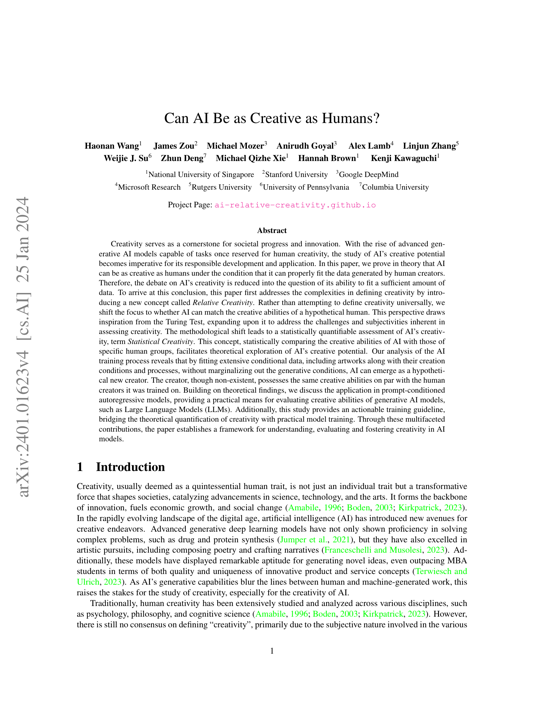

In [30]:
import pymupdf
from PIL import Image
import io

pdf_path = "data/raw/pdfs/2401.01623.pdf"
max_pages = 5
dpi = 192

doc = pymupdf.open(pdf_path)
n_total = doc.page_count
n = min(max_pages, n_total)

pages = []
for i in range(n):
    pix = doc[i].get_pixmap(dpi=dpi)
    img = Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")
    pages.append(img)
doc.close()

print(f"PDF total pages: {n_total}, loaded: {n}")
print(f"First page size: {pages[0].size}")

pages[0].resize((pages[0].width // 3, pages[0].height // 3))

In [31]:
import time

# Construit le batch complet (toutes les pages d'un coup)
batch = [BatchInputItem(image=img, prompt_type="ocr_layout") for img in pages]

t0 = time.time()
# generate_vllm gère le parallélisme côté client via ThreadPoolExecutor (max_workers).
# vLLM côté serveur batche les requêtes automatiquement (continuous batching).
results = generate_vllm(
    batch,
    # 4096 = 7s/page, 8000 = 17s/page ?
    max_output_tokens=8000,
    max_workers=8,   
)
total = time.time() - t0

per_page_md = []
per_page_stats = []
for i, result in enumerate(results):
    md = parse_markdown(result.raw)
    per_page_md.append(md)
    per_page_stats.append({
        "page": i,
        "tokens": result.token_count,
        "n_chars": len(md),
        "error": result.error,
    })
    print(f"page {i+1}/{len(pages)}: {result.token_count} tokens, {len(md)} chars{' [ERROR]' if result.error else ''}")

print(f"\nTotal: {total:.1f}s, mean: {total/len(pages):.1f}s/page")

page 1/5: 1412 tokens, 4399 chars
page 2/5: 1269 tokens, 4419 chars
page 3/5: 902 tokens, 4137 chars
page 4/5: 1292 tokens, 4616 chars
page 5/5: 1716 tokens, 4219 chars

Total: 33.7s, mean: 6.7s/page


In [5]:
from pathlib import Path

pdf_name = Path(pdf_path).stem
output_md = Path(f"data/ocr_hf/{pdf_name}_test2_2containers.md")   # ← juste le dossier de sortie change
output_md.parent.mkdir(parents=True, exist_ok=True)

full = f"<!-- Source: {Path(pdf_path).name} -->\n\n"
for i, md in enumerate(per_page_md):
    full += f"\n\n<!-- ===== Page {i+1} ===== -->\n\n"
    full += md
    full += "\n"

output_md.write_text(full)
print(f"Wrote {output_md} ({len(full)} chars)")

Wrote data/ocr_hf/2401.01623_test2_2containers.md (21983 chars)
